In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("students_mental_health_survey.csv")

# Create target variable (Depression: score >= 3 → 1, else 0)
df['Depression_Status'] = (df['Depression_Score'] >= 3).astype(int)

# Drop original score column
df = df.drop(columns=['Depression_Score'])

In [39]:
# Basic data overview
print("1. Dataset shape:", df.shape)

print("\n2. Column information:")
print(df.info())

print("\n3. Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n4. Number of duplicate rows:")
print(df.duplicated().sum())

print("\n5. Descriptive statistics:")
display(df.describe())

1. Dataset shape: (7022, 20)

2. Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7022 entries, 0 to 7021
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7022 non-null   int64  
 1   Course                       7022 non-null   object 
 2   Gender                       7022 non-null   object 
 3   CGPA                         7010 non-null   float64
 4   Stress_Level                 7022 non-null   int64  
 5   Anxiety_Score                7022 non-null   int64  
 6   Sleep_Quality                7022 non-null   object 
 7   Physical_Activity            7022 non-null   object 
 8   Diet_Quality                 7022 non-null   object 
 9   Social_Support               7022 non-null   object 
 10  Relationship_Status          7022 non-null   object 
 11  Substance_Use                7007 non-null   object 
 12  Counseling_Service_Use 

,Age,CGPA,Stress_Level,Anxiety_Score,Financial_Stress,Semester_Credit_Load,Depression_Status
count,7022.000000,7010.00000,7022.000000,7022.000000,7022.000000,7022.000000,7022.000000
mean,23.003418,3.49127,2.427941,2.300484,2.453005,22.010538,0.443606
std,3.853978,0.28742,1.638408,1.624305,1.708995,4.358380,0.496845
min,18.000000,2.44000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,20.000000,3.29000,1.000000,1.000000,1.000000,18.000000,0.000000
50%,22.000000,3.50000,2.000000,2.000000,2.000000,22.000000,0.000000
75%,25.000000,3.70000,4.000000,4.000000,4.000000,26.000000,1.000000
max,35.000000,4.00000,5.000000,5.000000,5.000000,29.000000,1.000000


In [40]:
# Fill Missing Values
# Numeric
df['CGPA'].fillna(df['CGPA'].median(), inplace=True)

# Categorical
df['Substance_Use'].fillna(df['Substance_Use'].mode()[0], inplace=True)

/tmp/ipykernel_3751/3820879035.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CGPA'].fillna(df['CGPA'].median(), inplace=True)
/tmp/ipykernel_3751/3820879035.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

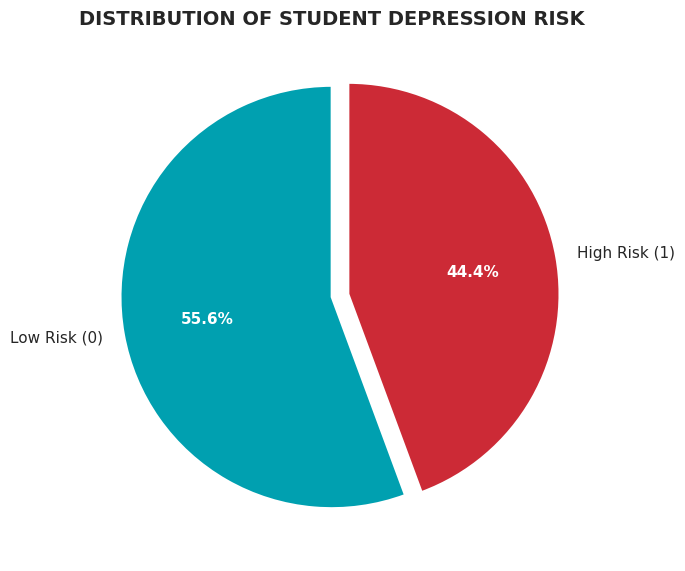

In [41]:
# Count number of observations for each class (0 = Low Risk, 1 = High Risk)
target_counts = df['Depression_Status'].value_counts().sort_index()

# Labels for the pie chart
labels = ['Low Risk (0)', 'High Risk (1)']

# Color scheme (blue = low risk, red = high risk)
colors = ['#00a0b0', '#cc2a36']

# Create figure
plt.figure(figsize=(7, 7))

# Plot pie chart
wedges, texts, autotexts = plt.pie(
    target_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.08),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)

# Improve percentage text visibility
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

# Title (uppercase for emphasis)
plt.title(
    'DISTRIBUTION OF STUDENT DEPRESSION RISK',
    fontsize=14,
    fontweight='bold'
)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display plot
plt.show()

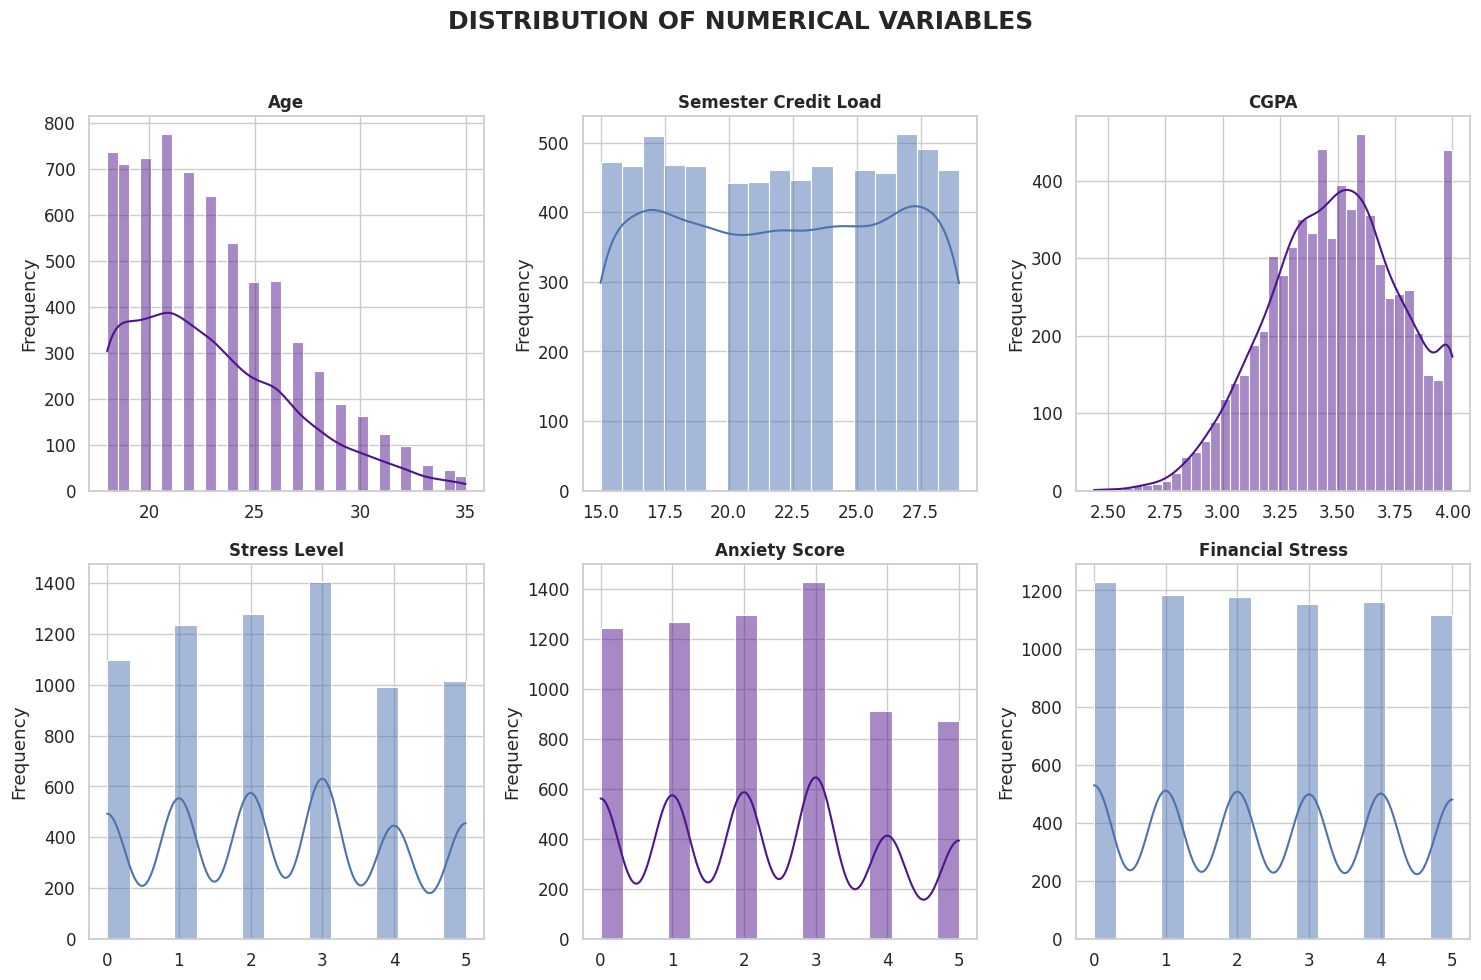

In [42]:
# Define numerical columns and colors
num_cols = ['Age', 'Semester_Credit_Load', 'CGPA',
            'Stress_Level', 'Anxiety_Score', 'Financial_Stress']
colors = ["#4C72B0", "#4e148c"]

# Set style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure
plt.figure(figsize=(15, 10))

# Plot histograms
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)

    sns.histplot(
        df[col],
        kde=True,
        color=colors[i % 2],
        edgecolor='white',
        linewidth=0.8
    )

    clean_name = col.replace('_', ' ')
    plt.title(clean_name, fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Frequency')

# Title and layout
plt.suptitle('Distribution of Numerical Variables'.upper(),
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show plot
plt.show()

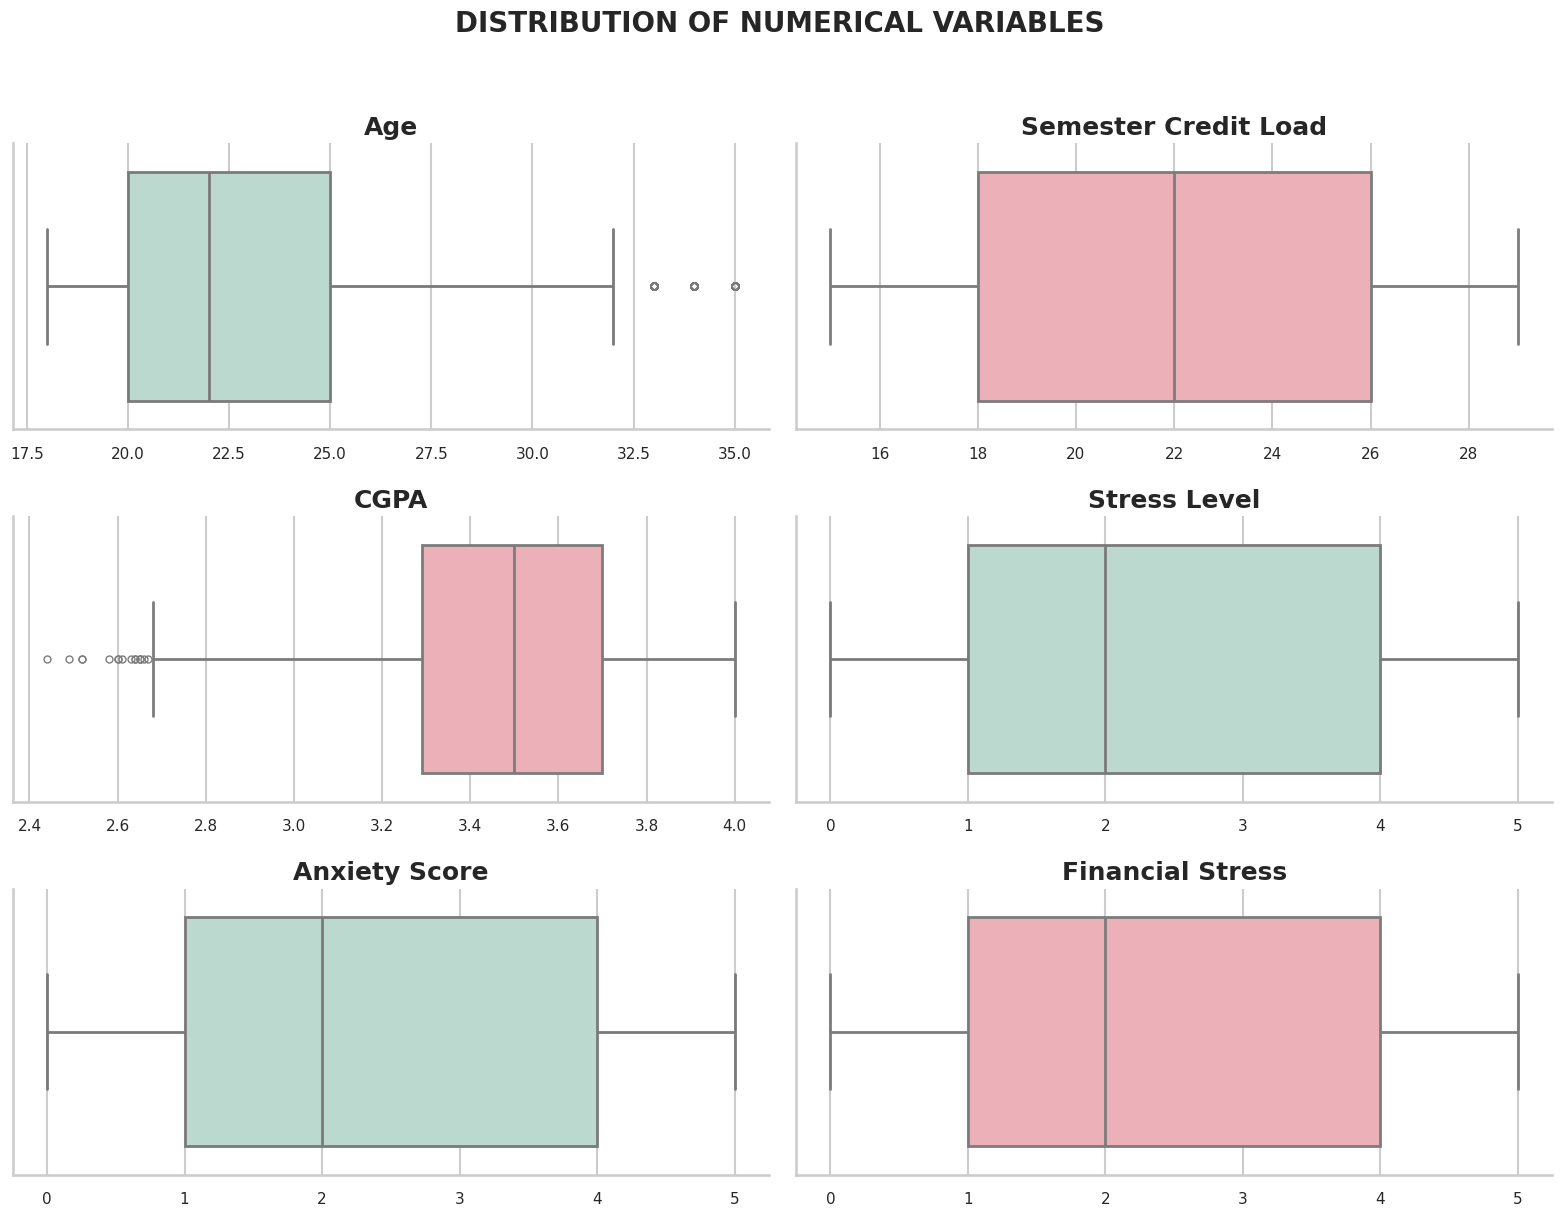

In [43]:
sns.set_style("whitegrid")
sns.set_context("talk")

colors = ['#b7ded2', '#f6a6b2']
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    row = i // 2
    col_idx = i % 2
    current_color = colors[(row + col_idx) % 2]

    sns.boxplot(
        x=df[col],
        ax=axes_flat[i],
        color=current_color,
        linewidth=2,
        fliersize=5
    )

    clean_title = col.replace('_', ' ')

    axes_flat[i].set_title(
        clean_title,
        fontsize=18,
        fontweight='bold'
    )

    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel("")
    axes_flat[i].tick_params(axis='x', labelsize=11)

fig.suptitle("DISTRIBUTION OF NUMERICAL VARIABLES",
             fontsize=20, fontweight='bold', y=1.02)

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3751/1145246302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3751/1145246302.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'])
/tmp/ipykernel_3751/1145246302.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3751/1145246302.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Low Risk (0)', 'High Risk (1)'])
/tmp/ipykernel_3751/1145246302.py:33: FutureWarning: 

Passing `palette` wi

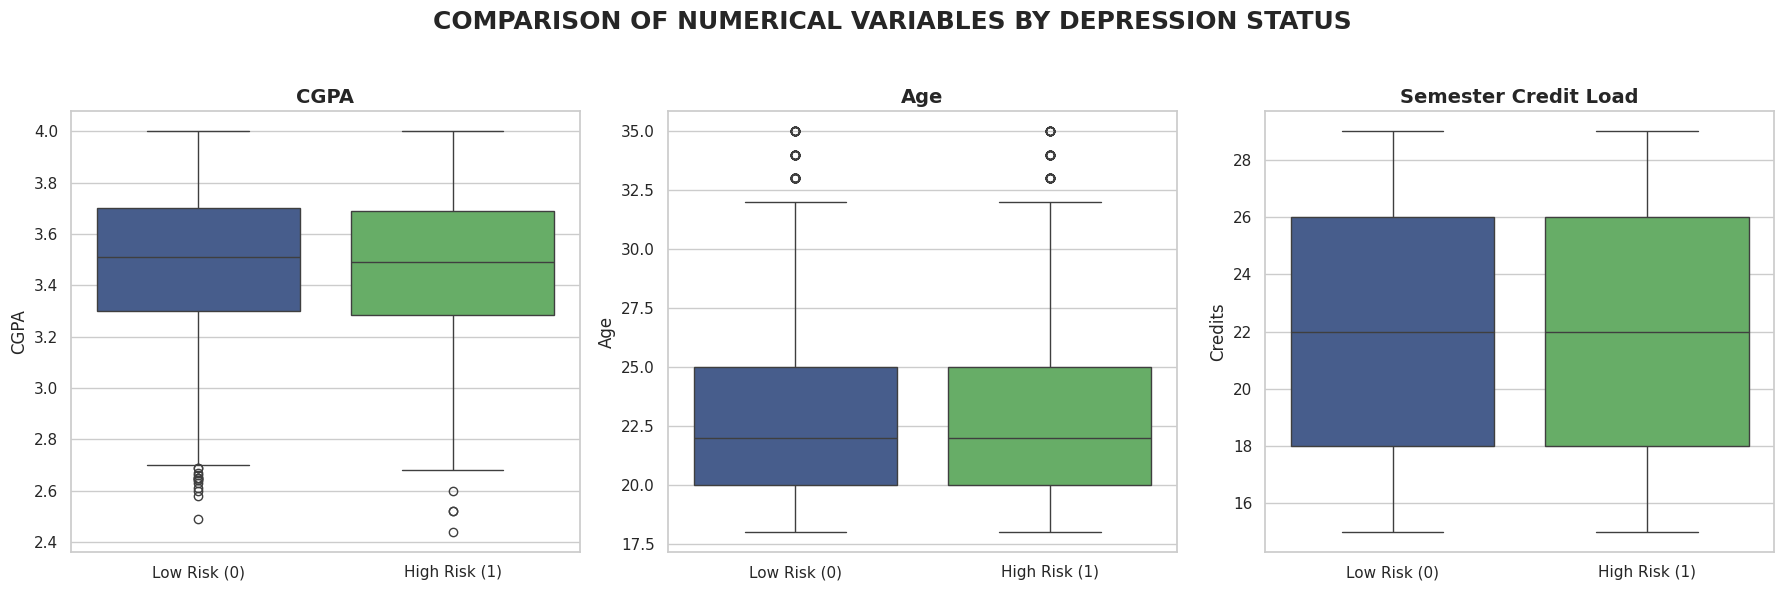

In [44]:
# Set theme and create subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = ["#3b5998", "#5cb85c"]

# Boxplot: CGPA vs Depression
sns.boxplot(
    ax=axes[0],
    x='Depression_Status',
    y='CGPA',
    data=df,
    palette=palette
)
axes[0].set_title('CGPA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('CGPA')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'])

# Boxplot: Age vs Depression
sns.boxplot(
    ax=axes[1],
    x='Depression_Status',
    y='Age',
    data=df,
    palette=palette
)
axes[1].set_title('Age', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Age')
axes[1].set_xticklabels(['Low Risk (0)', 'High Risk (1)'])

# Boxplot: Credit Load vs Depression
sns.boxplot(
    ax=axes[2],
    x='Depression_Status',
    y='Semester_Credit_Load',
    data=df,
    palette=palette
)
axes[2].set_title('Semester Credit Load', fontsize=14, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Credits')
axes[2].set_xticklabels(['Low Risk (0)', 'High Risk (1)'])

# Main title and layout
plt.suptitle(
    'Comparison of Numerical Variables by Depression Status'.upper(),
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show plot
plt.show()

/tmp/ipykernel_3751/2515459711.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_3751/2515459711.py:23: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.countplot(
/tmp/ipykernel_3751/2515459711.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_3751/2515459711.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_3751/2515459711.py:23: UserWarning: The palette list has more values (6) than needed (3), which may no

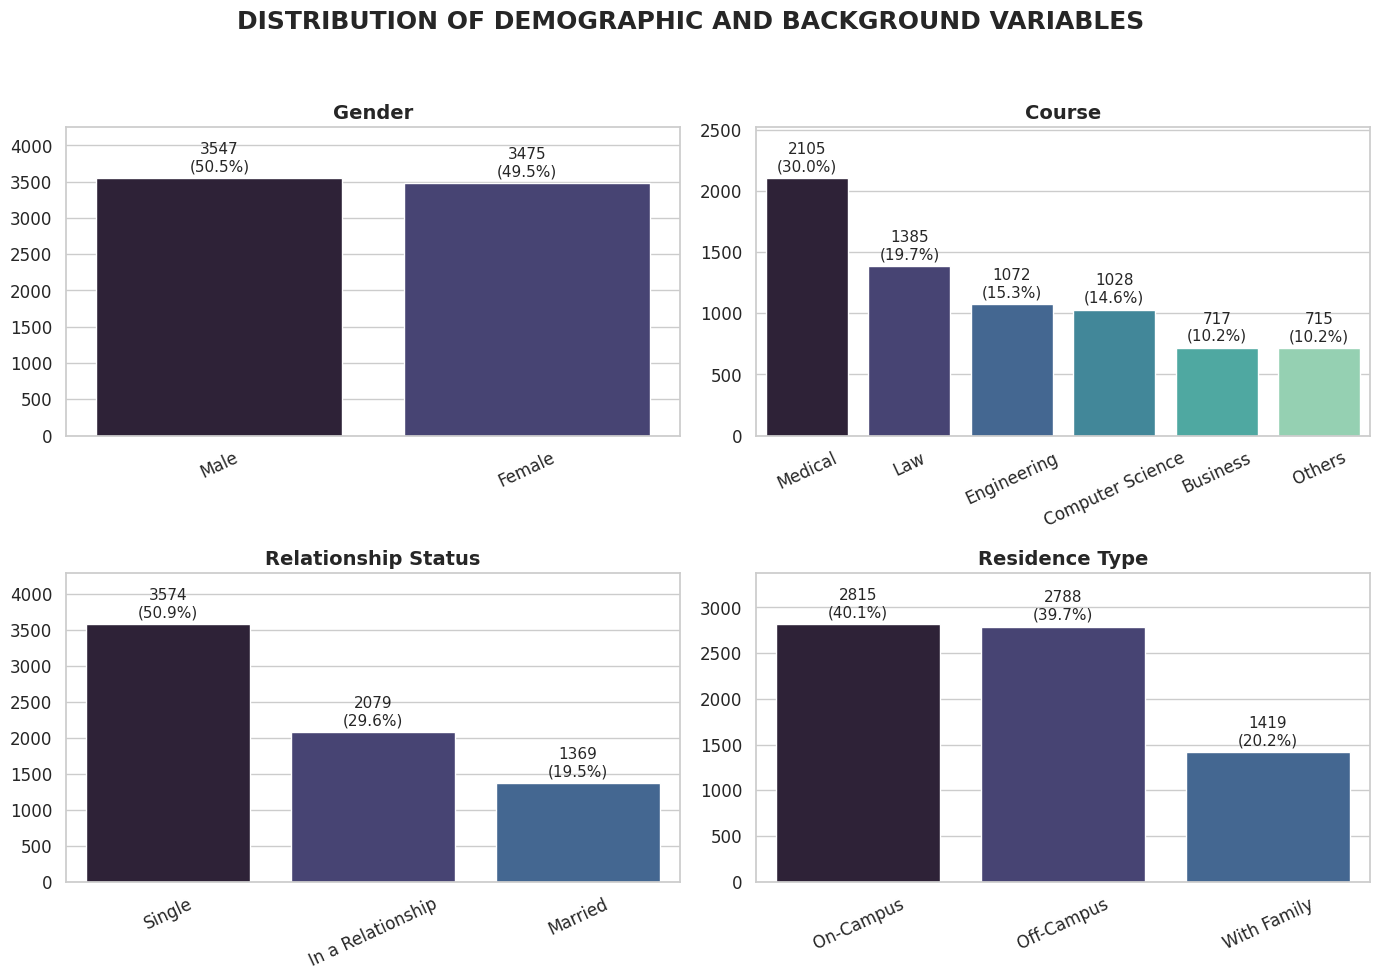

In [45]:
# Set context
sns.set_context("notebook", font_scale=1.1)

# Define categorical variables
group1 = [
    'Gender',
    'Course',
    'Relationship_Status',
    'Residence_Type'
]

# Create figure
plt.figure(figsize=(14, 10))
palette = sns.color_palette("mako")

# Plot countplots
for i, col in enumerate(group1, 1):
    plt.subplot(2, 2, i)

    counts = df[col].value_counts()
    total = len(df[col].dropna())

    ax = sns.countplot(
        data=df,
        x=col,
        order=counts.index,
        palette=palette
    )

    # Adjust y-axis limit
    max_count = counts.max()
    ax.set_ylim(0, max_count * 1.2)

    # Add count and percentage labels
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * count / total

        ax.annotate(
            f'{count}\n({percent:.1f}%)',
            (p.get_x() + p.get_width()/2., count),
            ha='center',
            va='bottom',
            fontsize=11,
            xytext=(0, 3),
            textcoords='offset points'
        )

    # Format titles and labels
    clean_name = col.replace('_', ' ')
    plt.title(clean_name, fontweight='bold', fontsize=14)

    plt.xticks(rotation=25)
    plt.xlabel('')
    plt.ylabel('')

# Main title and layout
plt.suptitle("Distribution of Demographic and Background Variables".upper(),
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show plot
plt.show()

/tmp/ipykernel_3751/789884096.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3751/789884096.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3751/789884096.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3751/789884096.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3751/789884096.py:33: FutureWarning: 

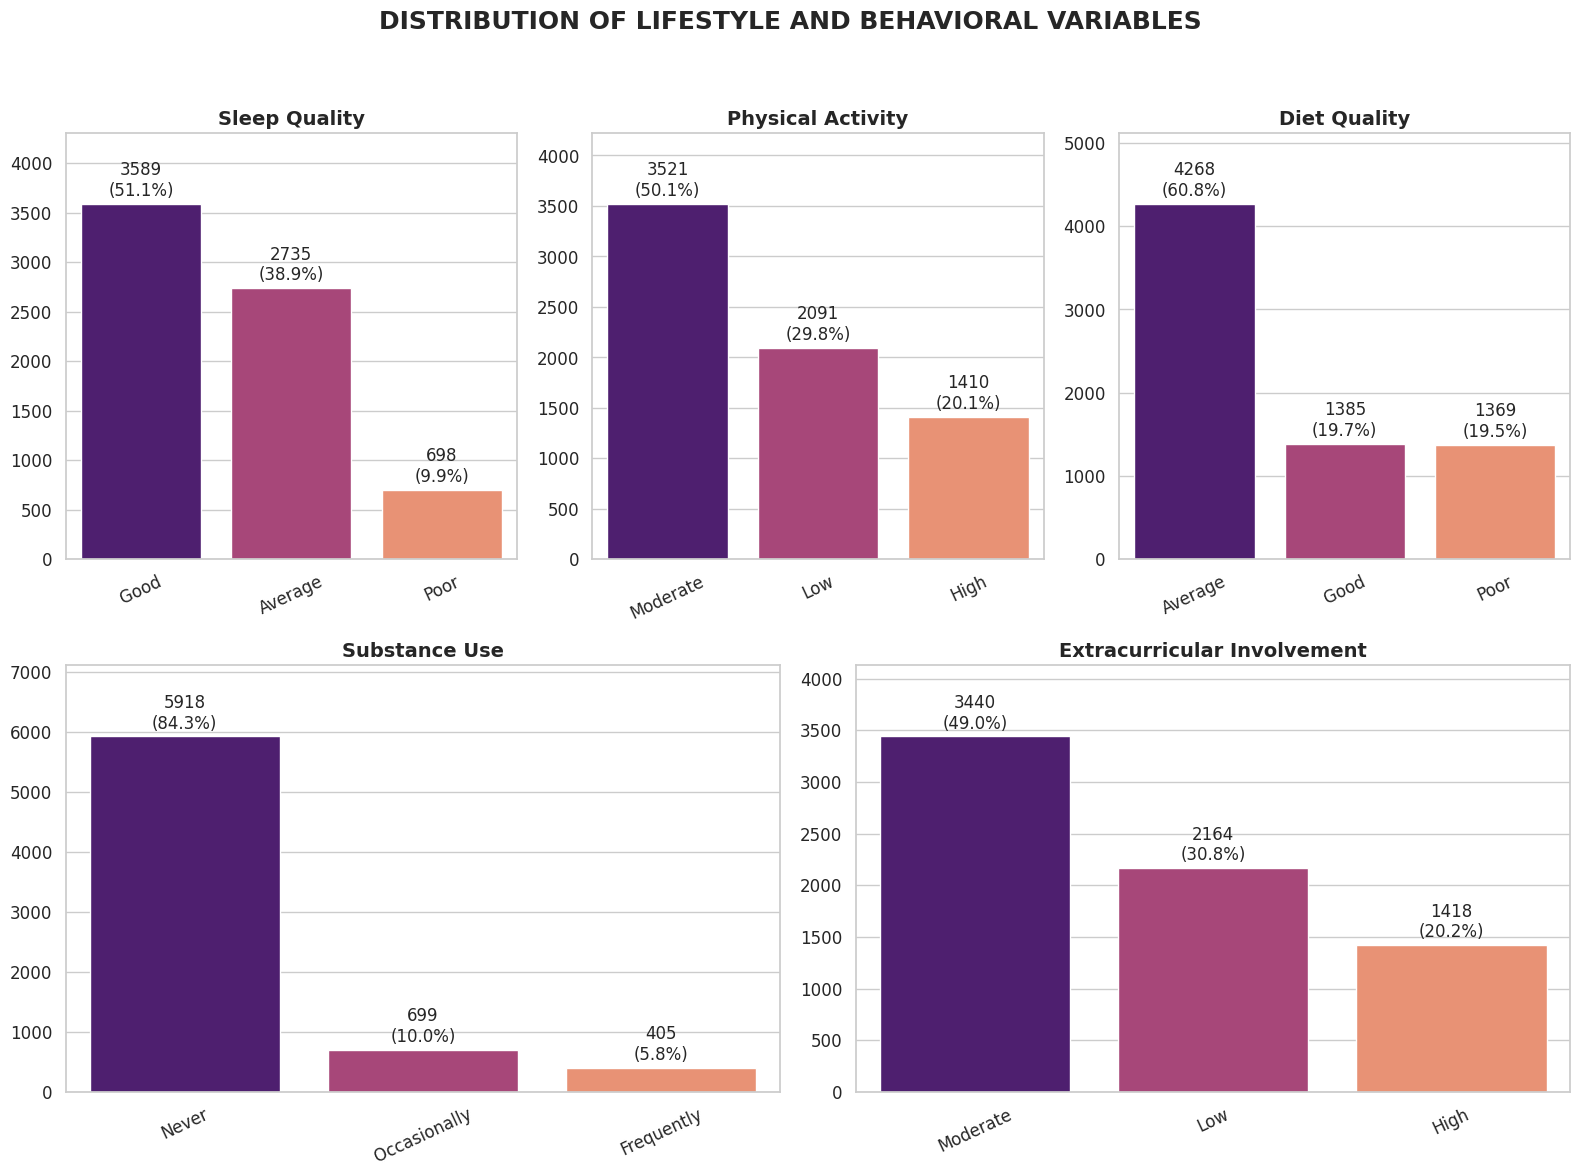

In [46]:
# Define categorical variables (lifestyle & behavior)
group2 = [
    'Sleep_Quality',
    'Physical_Activity',
    'Diet_Quality',
    'Substance_Use',
    'Extracurricular_Involvement'
]

# Set style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure and grid layout
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 6)

# Define subplot positions
axes = []
axes.append(fig.add_subplot(gs[0, 0:2]))
axes.append(fig.add_subplot(gs[0, 2:4]))
axes.append(fig.add_subplot(gs[0, 4:6]))
axes.append(fig.add_subplot(gs[1, 0:3]))
axes.append(fig.add_subplot(gs[1, 3:6]))

# Plot countplots
for ax, col in zip(axes, group2):
    counts = df[col].value_counts()
    total = len(df[col].dropna())

    palette = sns.color_palette("magma", n_colors=len(counts))

    sns.countplot(
        data=df,
        x=col,
        order=counts.index,
        palette=palette,
        ax=ax
    )

    # Adjust y-axis limit
    max_count = counts.max()
    ax.set_ylim(0, max_count * 1.2)

    # Add count and percentage labels
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * count / total

        ax.annotate(
            f'{count}\n({percent:.1f}%)',
            (p.get_x() + p.get_width()/2., count),
            ha='center',
            va='bottom',
            fontsize=12,
            xytext=(0, 3),
            textcoords='offset points'
        )

    # Format titles and labels
    clean_name = col.replace('_', ' ')
    ax.set_title(clean_name, fontweight='bold', fontsize=14)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=25)

# Main title and layout
fig.suptitle(
    "Distribution of Lifestyle and Behavioral Variables".upper(),
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show plot
plt.show()

/tmp/ipykernel_3751/2414404045.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_3751/2414404045.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.countplot(
/tmp/ipykernel_3751/2414404045.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_3751/2414404045.py:24: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.countplot(
/tmp/ipykernel_3751/2414404045.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

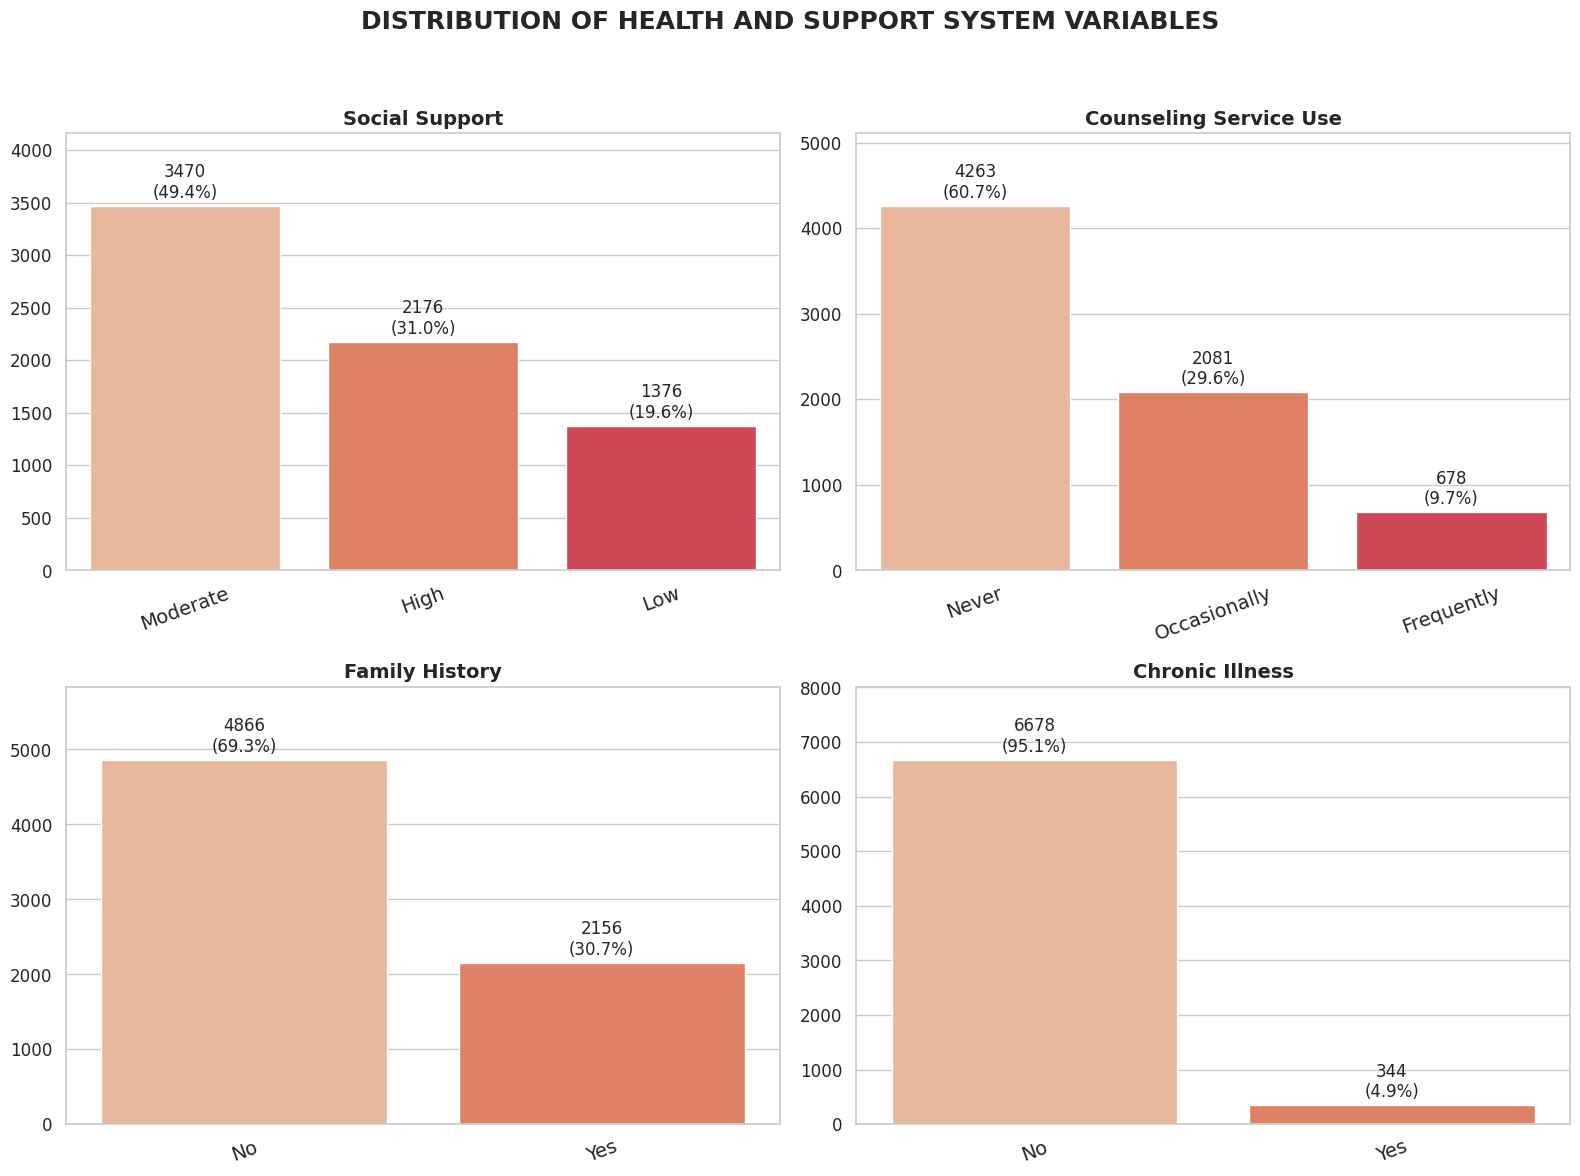

In [47]:
# Define categorical variables (health & support)
group3 = [
    'Social_Support',
    'Counseling_Service_Use',
    'Family_History',
    'Chronic_Illness'
]

# Set style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure
plt.figure(figsize=(16, 12))

# Plot countplots
for i, col in enumerate(group3, 1):
    plt.subplot(2, 2, i)

    counts = df[col].value_counts()
    total = len(df[col].dropna())

    palette = sns.color_palette("rocket_r")
    ax = sns.countplot(
        data=df,
        x=col,
        order=counts.index,
        palette=palette
    )

    # Adjust y-axis limit
    max_count = counts.max()
    ax.set_ylim(0, max_count * 1.2)

    # Add count and percentage labels
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * count / total

        ax.annotate(
            f'{count}\n({percent:.1f}%)',
            (p.get_x() + p.get_width()/2., count),
            ha='center',
            va='bottom',
            fontsize=12,
            xytext=(0, 3),
            textcoords='offset points'
        )

    # Format titles and labels
    clean_name = col.replace('_', ' ')
    plt.title(clean_name, fontweight='bold', fontsize=14)

    plt.xticks(rotation=20, fontsize=14)
    plt.xlabel('')
    plt.ylabel('')

# Main title and layout
plt.suptitle(
    "Distribution of Health and Support System Variables".upper(),
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show plot
plt.show()

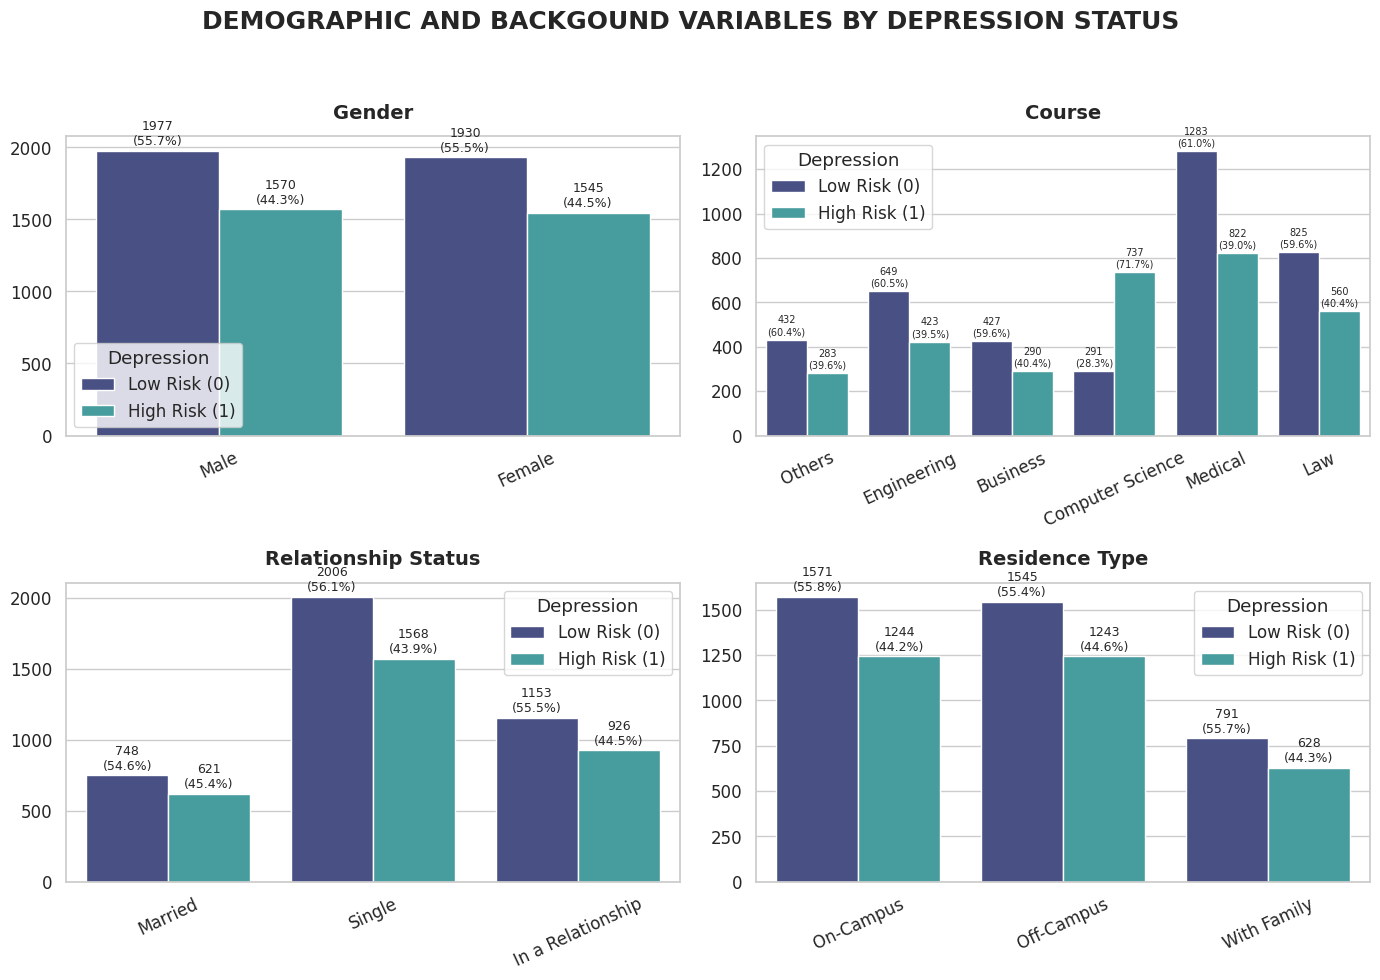

In [48]:
# Set style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Define categorical variables
group1 = [
    'Gender',
    'Course',
    'Relationship_Status',
    'Residence_Type'
]

# Create figure
plt.figure(figsize=(14, 10))
palette = sns.color_palette("mako", n_colors=2)

# Plot countplots with hue
for i, col in enumerate(group1, 1):
    plt.subplot(2, 2, i)

    ax = sns.countplot(
        data=df,
        x=col,
        hue='Depression_Status',
        palette=palette
    )

    # Calculate percentage table
    ct = pd.crosstab(df[col], df['Depression_Status'])
    ct_percent = ct.div(ct.sum(axis=1), axis=0)

    # Adjust font size based on number of categories
    n_cat = len(ct)
    if n_cat >= 6:
        fsize = 7
    elif n_cat >= 4:
        fsize = 8
    else:
        fsize = 9

    # Add count and percentage labels
    for container in ax.containers:
        for i_bar, bar in enumerate(container):
            height = bar.get_height()
            if height == 0:
                continue

            x = bar.get_x() + bar.get_width() / 2.
            category = ax.get_xticklabels()[i_bar].get_text()
            hue_index = ax.containers.index(container)

            try:
                percent = ct_percent.loc[category].iloc[hue_index] * 100
            except:
                percent = 0

            ax.annotate(
                f'{int(height)}\n({percent:.1f}%)',
                (x, height),
                ha='center',
                va='bottom',
                fontsize=fsize,
                xytext=(0, 2),
                textcoords='offset points'
            )

    # Format titles and labels
    clean_name = col.replace('_', ' ')
    plt.title(clean_name, fontweight='bold', pad=13, fontsize=14)

    plt.xticks(rotation=25)
    plt.xlabel('')
    plt.ylabel('')

    # Customize legend
    ax.legend(
        title='Depression',
        labels=['Low Risk (0)', 'High Risk (1)']
    )

# Main title and layout
plt.suptitle(
    "Demographic and Backgound Variables by Depression Status".upper(),
    fontsize=18,
    fontweight='bold'
)

plt.subplots_adjust(hspace=0.4)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show plot
plt.show()

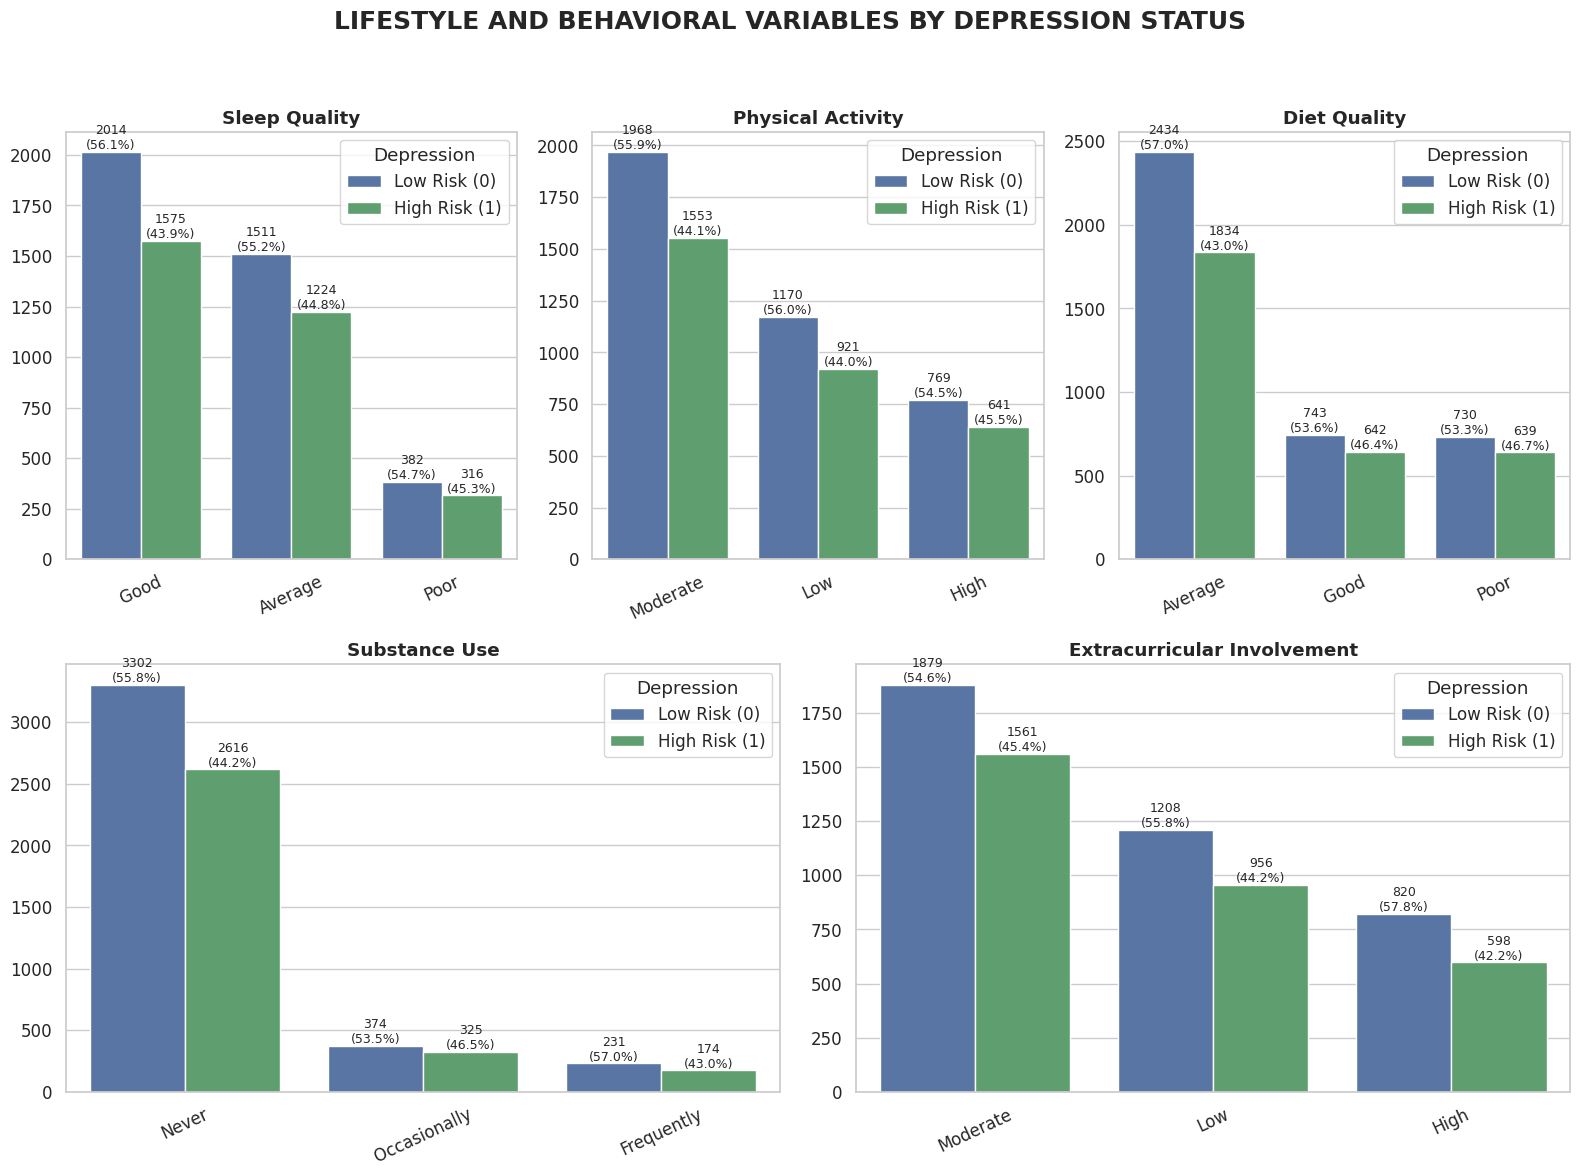

In [49]:
# Define categorical variables (lifestyle & behavior)
group2 = [
    'Sleep_Quality',
    'Physical_Activity',
    'Diet_Quality',
    'Substance_Use',
    'Extracurricular_Involvement'
]

# Set style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure and grid layout
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 6)

# Define color palette for target
palette = ['#4C72B0', '#55A868']

# Create subplot positions
axes = []
axes.append(fig.add_subplot(gs[0, 0:2]))
axes.append(fig.add_subplot(gs[0, 2:4]))
axes.append(fig.add_subplot(gs[0, 4:6]))
axes.append(fig.add_subplot(gs[1, 0:3]))
axes.append(fig.add_subplot(gs[1, 3:6]))

# Plot countplots with hue
for ax, col in zip(axes, group2):

    # Countplot with target
    sns.countplot(
        data=df,
        x=col,
        hue='Depression_Status',
        order=df[col].value_counts().index,
        palette=palette,
        ax=ax
    )

    # Calculate percentage table
    ct = pd.crosstab(df[col], df['Depression_Status'])
    ct_percent = ct.div(ct.sum(axis=1), axis=0)

    # Add count and percentage labels
    for container in ax.containers:
        labels = []
        for i, bar in enumerate(container):
            height = bar.get_height()

            if height == 0:
                labels.append('')
                continue

            category = ax.get_xticklabels()[i].get_text()
            hue_index = ax.containers.index(container)

            try:
                percent = ct_percent.loc[category].iloc[hue_index] * 100
            except:
                percent = 0

            labels.append(f'{int(height)}\n({percent:.1f}%)')

        ax.bar_label(container, labels=labels, fontsize=9)

    # Format titles and labels
    clean_name = col.replace('_', ' ')
    ax.set_title(clean_name, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=25)

    # Customize legend
    ax.legend(
        title='Depression',
        labels=['Low Risk (0)', 'High Risk (1)']
    )

# Main title and layout
fig.suptitle("Lifestyle and Behavioral variables BY Depression Status".upper(),
             fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show plot
plt.show()

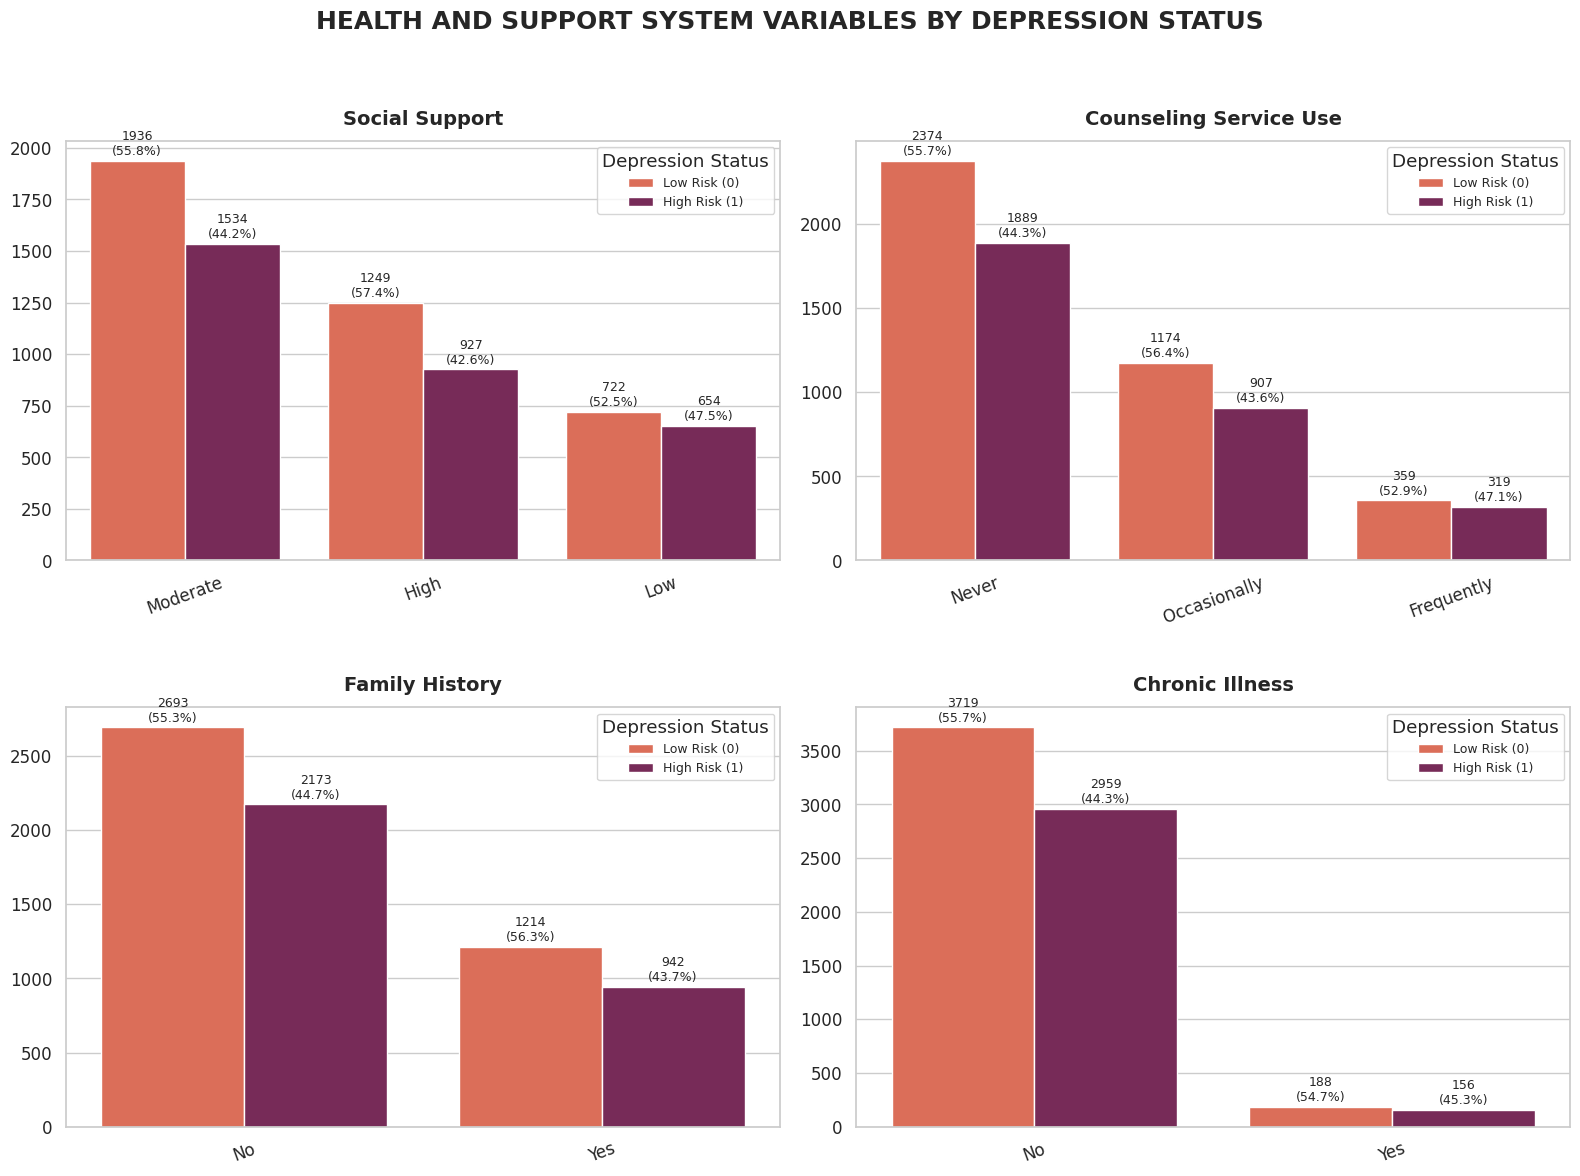

In [50]:
# Define categorical variables (health & support)
group3 = [
    'Social_Support',
    'Counseling_Service_Use',
    'Family_History',
    'Chronic_Illness'
]

# Create figure and set style
plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Define color palette for target
palette = sns.color_palette("rocket_r", n_colors=2)

# Plot countplots with hue
for i, col in enumerate(group3, 1):
    plt.subplot(2, 2, i)

    counts = df[col].value_counts()

    ax = sns.countplot(
        data=df,
        x=col,
        hue='Depression_Status',
        order=counts.index,
        palette=palette
    )

    # Calculate percentage table
    ct = pd.crosstab(df[col], df['Depression_Status'])
    ct_percent = ct.div(ct.sum(axis=1), axis=0)

    # Adjust font size
    n_cat = len(ct)
    if n_cat >= 6:
        fsize = 8
    else:
        fsize = 9

    # Add count and percentage labels
    for container in ax.containers:
        labels = []
        for i_bar, bar in enumerate(container):
            height = bar.get_height()

            if height == 0:
                labels.append('')
                continue

            category = ax.get_xticklabels()[i_bar].get_text()
            hue_index = ax.containers.index(container)

            try:
                percent = ct_percent.loc[category].iloc[hue_index] * 100
            except:
                percent = 0

            labels.append(f'{int(height)}\n({percent:.1f}%)')

        ax.bar_label(container, labels=labels, fontsize=fsize, padding=2)

    # Format titles and labels
    clean_name = col.replace('_', ' ')
    plt.title(clean_name, fontweight='bold', pad=12, fontsize=14)

    plt.xticks(rotation=20)
    plt.xlabel('')
    plt.ylabel('')

    # Customize legend
    ax.legend(
        title='Depression Status',
        labels=['Low Risk (0)', 'High Risk (1)'],
        fontsize=9
    )

# Main title and layout
plt.suptitle(
    "Health and Support System Variables by Depression Status".upper(),
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.35)

# Show plot
plt.show()

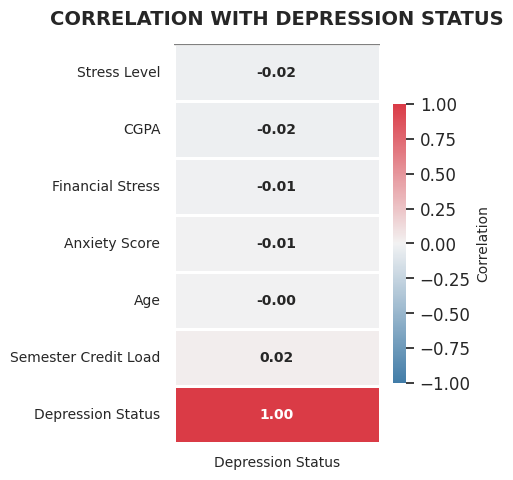

In [51]:
# Ensure target is numeric
if df['Depression_Status'].dtype == 'object':
    df['Depression_Status'] = df['Depression_Status'].map({
        'Low': 0,
        'High': 1
    })

# Compute correlation
corr = df.corr(numeric_only=True)
corr_target = corr[['Depression_Status']].sort_values(by='Depression_Status')
corr_target.index = corr_target.index.str.replace('_', ' ')
corr_target.columns = corr_target.columns.str.replace('_', ' ')
# Create figure
plt.figure(figsize=(5, 5))

# Define color map
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# Plot heatmap
ax = sns.heatmap(
    corr_target,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={'shrink': 0.7, 'label': 'Correlation'}
)
cbar = ax.collections[0].colorbar
cbar.set_label('Correlation', fontsize=10)

# Title and formatting
plt.title(
    "Correlation with Depression Status".upper(),
    fontsize=14,
    fontweight='bold',
    pad=14
)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Add horizontal line
ax.axhline(y=0, color='gray', linewidth=1)

# Adjust layout and show
plt.tight_layout()
plt.show()

In [52]:
# Text Normalization
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip().str.lower()

In [53]:
# Encoding Categorical Data
# Binary (Yes/No)
binary_cols = ['Family_History',
               'Chronic_Illness']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


# Ordinal
ordinal_cols = ['Sleep_Quality',
                'Physical_Activity',
                'Diet_Quality',
                'Social_Support',
                'Substance_Use',
                'Counseling_Service_Use',
                'Extracurricular_Involvement']

ordinal_mappings = {
    'Sleep_Quality': {'poor': 1, 'average': 2, 'good': 3},
    'Physical_Activity': {'low': 1, 'moderate': 2, 'high': 3},
    'Diet_Quality': {'poor': 1, 'average': 2, 'good': 3},
    'Social_Support': {'low': 1, 'moderate': 2, 'high': 3},
    'Extracurricular_Involvement': {'low': 1, 'moderate': 2, 'high': 3},
    'Substance_Use': {'never': 1, 'occasionally': 2, 'frequently': 3},
    'Counseling_Service_Use': {'never': 1, 'occasionally': 2, 'frequently': 3}
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

In [54]:
from sklearn.model_selection import train_test_split
# 1. Split the original dataset
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Depression_Status']
)
# 2. Separate features (X) and target (y) from each subset
# Training set
y_train = train_df['Depression_Status']
X_train_raw = train_df.drop(columns=['Depression_Status'])
# Testing set
y_test = test_df['Depression_Status']
X_test_raw = test_df.drop(columns=['Depression_Status'])

In [55]:
from scipy.stats import chi2_contingency
# 1. List of categorical features to be tested
cat_cols = [
    'Gender', 'Course', 'Sleep_Quality', 'Physical_Activity',
    'Diet_Quality', 'Social_Support', 'Relationship_Status',
    'Substance_Use', 'Counseling_Service_Use', 'Family_History',
    'Chronic_Illness', 'Extracurricular_Involvement',
    'Residence_Type'
]
# 2. Initialize results list
results = []
# 3. Perform Chi-square test using TRAINING DATA ONLY
for col in cat_cols:
    # Create contingency table between feature and target (train set)
    table = pd.crosstab(train_df[col], train_df['Depression_Status'])
    # Apply Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({
        'Feature': col,
        'Chi2': chi2,
        'p-value': p
    })
# 4. Convert results to DataFrame and sort by p-value
chi_df = pd.DataFrame(results).sort_values(by='p-value')

# 5. Display results (used for feature selection)
print("CHI-SQUARE RESULTS (TRAIN SET ONLY)")
print(chi_df)

CHI-SQUARE RESULTS (TRAIN SET ONLY)
                        Feature        Chi2       p-value
1                        Course  286.145750  9.516668e-60
5                Social_Support    9.928500  6.983187e-03
4                  Diet_Quality    9.511333  8.602809e-03
6           Relationship_Status    3.388621  1.837259e-01
11  Extracurricular_Involvement    2.399465  3.012748e-01
8        Counseling_Service_Use    1.915542  3.837473e-01
7                 Substance_Use    1.784317  4.097704e-01
9                Family_History    0.490954  4.835020e-01
3             Physical_Activity    1.252101  5.346994e-01
10              Chronic_Illness    0.286398  5.925383e-01
2                 Sleep_Quality    0.833927  6.590451e-01
0                        Gender    0.144096  7.042426e-01
12               Residence_Type    0.085712  9.580491e-01


In [56]:
# 1. Create a copy of X_train_raw to avoid modifying the original data
X_train_tmp = X_train_raw.copy()
# 2. Encode categorical variables into numeric format (for Random Forest)
X_train_encoded = pd.get_dummies(X_train_tmp, drop_first=True)

In [57]:
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest model on the encoded training data
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train_encoded, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [58]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance.head(10))

                        Feature  Importance
1                          CGPA    0.137252
0                           Age    0.096175
14         Semester_Credit_Load    0.095641
3                 Anxiety_Score    0.066696
12             Financial_Stress    0.066316
2                  Stress_Level    0.065775
15      Course_computer science    0.043222
5             Physical_Activity    0.039496
13  Extracurricular_Involvement    0.039438
7                Social_Support    0.036322


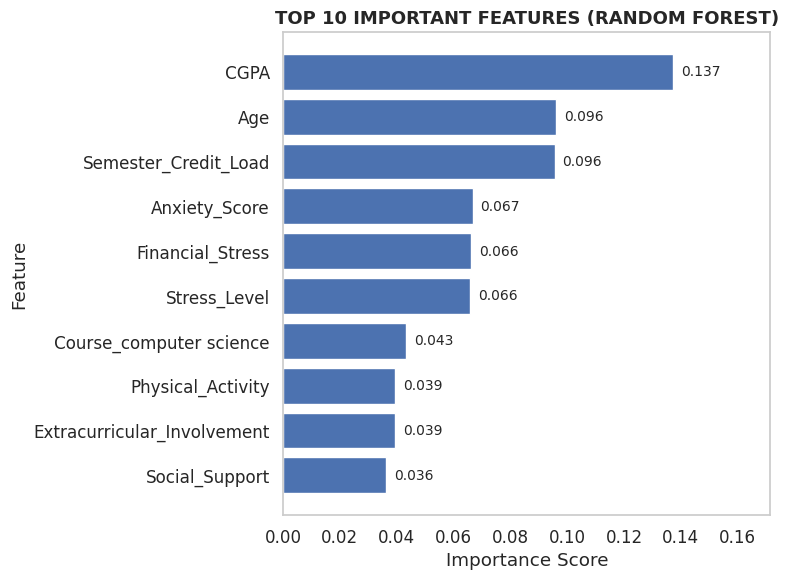

In [59]:
# Select top 10 features
top10 = feature_importance.head(10)

# Create figure
plt.figure(figsize=(8, 6))

# Plot horizontal bar chart
bars = plt.barh(top10['Feature'], top10['Importance'])

# Invert y-axis (highest on top)
plt.gca().invert_yaxis()

# Adjust x-axis limit
max_val = top10['Importance'].max()
plt.xlim(0, max_val * 1.25)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max_val*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center',
        fontsize=10
    )

# Title and labels
plt.title("Top 10 Important Features (Random Forest)".upper(), fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Final layout
plt.grid(False)
plt.tight_layout()
plt.show()

In [60]:
# Create full feature set by encoding categorical variables
X_train_full = pd.get_dummies(X_train_raw, drop_first=True)
X_test_full = pd.get_dummies(X_test_raw, drop_first=True)
# Align test set columns with training set
X_test_full = X_test_full.reindex(columns=X_train_full.columns, fill_value=0)
print(f"X_train_full: {X_train_full.shape[1]} columns")
print(f"X_test_full: {X_test_full.shape[1]} columns")

X_train_full: 25 columns
X_test_full: 25 columns


In [61]:
# Get original feature names (for mapping)
all_original_cols = X_train_raw.columns.tolist()
# Select top important features from Random Forest
rf_top = feature_importance.head(6)['Feature']
rf_selected = set()
# Map encoded (dummy) features back to original features
for feat in rf_top:
    for col in all_original_cols:
        if feat.startswith(col):
            rf_selected.add(col)
print("Selected features from RF:", rf_selected)
# Combine with Chi-square selected features
chi_selected = ['Course', 'Diet_Quality', 'Social_Support']
final_features = list(set(chi_selected) | rf_selected)
print("\nFinal selected features (SELECTED):", final_features)
# --- Create SELECTED dataset ---
# Subset original data with selected features
X_train_selected_raw = X_train_raw[final_features]
X_test_selected_raw = X_test_raw[final_features]
# Encode categorical variables
X_train_selected = pd.get_dummies(X_train_selected_raw, drop_first=True)
X_test_selected = pd.get_dummies(X_test_selected_raw, drop_first=True)
# Align test set with training set
X_test_selected = X_test_selected.reindex(columns=X_train_selected.columns, fill_value=0)
print(f"\nSELECTED dataset shape: Train {X_train_selected.shape}, Test {X_test_selected.shape}")

Selected features from RF: {'Stress_Level', 'Age', 'Financial_Stress', 'CGPA', 'Semester_Credit_Load', 'Anxiety_Score'}

Final selected features (SELECTED): ['Stress_Level', 'Age', 'Financial_Stress', 'CGPA', 'Diet_Quality', 'Course', 'Semester_Credit_Load', 'Social_Support', 'Anxiety_Score']

SELECTED dataset shape: Train (5617, 13), Test (1405, 13)


In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Standardization applied to selected features
X_train_sel_scaled = scaler.fit_transform(X_train_selected)
X_test_sel_scaled = scaler.transform(X_test_selected)
# Standardization applied to the full feature set
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(random_state=42)
}
# Train and evaluate on SELECTED dataset
print("="*20 + " RESULTS ON SELECTED DATASET " + "="*20)
for name, model in models.items():
    model.fit(X_train_sel_scaled, y_train)  # train model
    y_pred = model.predict(X_test_sel_scaled)  # make predictions
    print(f"\nModel: {name} (Selected)")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
print("\n" + "-" * 75 + "\n")
# Train and evaluate on FULL dataset
print("="*20 + " RESULTS ON FULL DATASET " + "="*20)
for name, model in models.items():
    model.fit(X_train_full_scaled, y_train)  # train model
    y_pred_full = model.predict(X_test_full_scaled)  # make predictions
    print(f"\nModel: {name} (Full)")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_full):.4f}")
    print(classification_report(y_test, y_pred_full))

==================== RESULTS ON SELECTED DATASET ====================

Model: Logistic Regression (Selected)
Accuracy: 0.6285
              precision    recall  f1-score   support

           0       0.61      0.91      0.73       782
           1       0.71      0.27      0.39       623

    accuracy                           0.63      1405
   macro avg       0.66      0.59      0.56      1405
weighted avg       0.66      0.63      0.58      1405


Model: SVM (Selected)
Accuracy: 0.6263
              precision    recall  f1-score   support

           0       0.61      0.90      0.73       782
           1       0.70      0.28      0.40       623

    accuracy                           0.63      1405
   macro avg       0.65      0.59      0.56      1405
weighted avg       0.65      0.63      0.58      1405


Model: Random Forest (Selected)
Accuracy: 0.5943
              precision    recall  f1-score   support

           0       0.61      0.76      0.68       782
           1       0.

In [64]:
# Ensure Logistic Regression is trained on SELECTED dataset
lr_model = models["Logistic Regression"]
lr_model.fit(X_train_sel_scaled, y_train)
# Create feature importance table (coefficient & odds ratio)
importance_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])  # e^beta
})
# Compute absolute coefficient for ranking
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)
# Display results
print("--- DETAILED FEATURE ANALYSIS (LOGISTIC REGRESSION) ---")
print(importance_df[['Feature', 'Coefficient', 'Odds_Ratio']].reset_index(drop=True))

--- DETAILED FEATURE ANALYSIS (LOGISTIC REGRESSION) ---
                    Feature  Coefficient  Odds_Ratio
0   Course_computer science     0.432816    1.541593
1            Course_medical    -0.080281    0.922857
2            Social_Support    -0.057422    0.944196
3      Semester_Credit_Load     0.056865    1.058513
4             Course_others    -0.051935    0.949390
5             Anxiety_Score     0.040169    1.040986
6                      CGPA    -0.038553    0.962181
7        Course_engineering    -0.033761    0.966803
8          Financial_Stress    -0.030798    0.969672
9                Course_law    -0.023668    0.976610
10             Diet_Quality     0.016758    1.016899
11             Stress_Level     0.015559    1.015680
12                      Age    -0.008297    0.991737


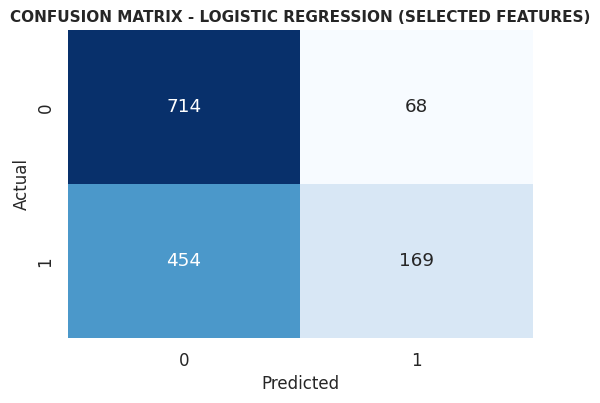

In [65]:
from sklearn.metrics import confusion_matrix
# Generate predictions
y_pred_lr = lr_model.predict(X_test_sel_scaled)
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
# Title and labels
plt.title('Confusion Matrix - Logistic Regression (Selected Features)'.upper(),
          fontsize=11, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
# Show plot
plt.show()

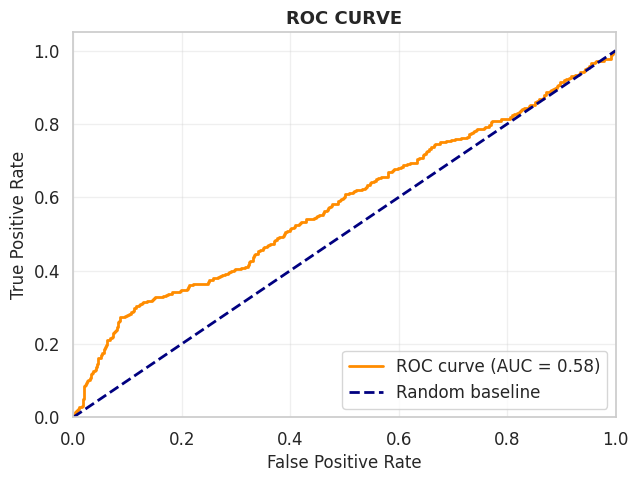

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score
# Compute predicted probabilities (15)
y_prob_lr = lr_model.predict_proba(X_test_sel_scaled)[:, 1]
# Calculate ROC metrics
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)
# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random baseline')
# Axis and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve'.upper(),
          fontsize=13, fontweight='bold')
# Legend and grid
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
# Show plot
plt.show()

In [67]:
# Compute accuracy on train and test sets
train_acc = lr_model.score(X_train_sel_scaled, y_train)
test_acc = lr_model.score(X_test_sel_scaled, y_test)
# Print results
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.6179
Test accuracy: 0.6285
